# Bước 3: Tạo Knowledge Graph từ NER Output

**Input:** `ner_labeled_data.csv` — output từ `labeling.ipynb` (13,900 bài báo, BIO labels)

**Pipeline:**
```
ner_labeled_data.csv
       ↓
 [1] Parse BIO → Entity Spans (PERSON, ORG, LOC, PRODUCT, EVENT, INDUSTRY, MONEY, DATE, PERCENT)
       ↓
 [2] Entity Normalization (coreference + alias resolution)
       ↓
 [3] Rule-based Relation Extraction (pattern cú pháp tiếng Việt)
       ↓
 [4] Triple Construction  →  (subject – relation – object)
       ↓
 [5] Triple Filtering & Confidence Scoring
       ↓
 [6] Knowledge Graph Build  →  NetworkX MultiDiGraph
       ↓
 [7] Export  →  triples.csv / triples.json / knowledge_graph.graphml / knowledge_graph.gexf
       ↓
 [8] Graph Statistics & Visualization
```

**Relation types được extract:**

| Relation | Ví dụ |
|----------|-------|
| `LÃNH_ĐẠO` | Nguyễn Văn A — CEO — Vingroup |
| `HỢP_TÁC` | BIDV — hợp tác — VPBank |
| `ĐẦU_TƯ` | Masayoshi Son — đầu tư — VNG |
| `SẢN_XUẤT` | Apple — sản xuất — iPhone 17 |
| `ĐẶT_TẠI` | Samsung — đặt tại — Hà Nội |
| `THUỘC_NGÀNH` | Vingroup — thuộc ngành — bất động sản |
| `TỔ_CHỨC_SỰ_KIỆN` | Apple — tổ chức — WWDC 2024 |
| `CÓ_GIÁ_TRỊ` | thỏa thuận — có giá trị — 1 tỷ USD |
| `XẢY_RA_TẠI` | sự kiện — xảy ra tại — TP.HCM |
| `THAM_GIA` | Elon Musk — tham gia — sự kiện |


## 0. Cài đặt thư viện

In [1]:
import subprocess, sys

pkgs = [
    'networkx>=3.2',
    'pandas>=2.0',
    'tqdm',
    'matplotlib',
    'lxml',          # cho graphml export
    'pyvis',         # interactive HTML visualization
    'unidecode',     # normalization
]
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs, check=True)
print('Done.')

Done.


## 1. Import & Config

In [5]:
import re
import json
import warnings
import unicodedata
from pathlib import Path
from typing import List, Tuple, Dict, Optional, Set
from collections import defaultdict, Counter
from dataclasses import dataclass, field, asdict

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── Config ──────────────────────────────────────────────────
CFG = {
    # Input
    'input_csv'          : 'CSV/ner_labeled_data.csv',  # output từ labeling.ipynb

    # Triple filtering
    'min_confidence'     : 0.5,    # loại triple có score < ngưỡng này
    'max_entity_length'  : 80,     # loại entity quá dài (noise)
    'min_entity_length'  : 2,      # loại entity quá ngắn
    'min_triple_freq'    : 1,      # giữ triple xuất hiện >= N lần

    # Graph
    'max_triples'        : None,   # None = không giới hạn; đặt số nhỏ để debug

    # Output
    'output_dir'         : 'knowledge_graph_output',

    # Viz
    'top_k_nodes_viz'    : 100,    # chỉ vẽ top-K node (degree cao nhất) cho rõ
}

OUT = Path(CFG['output_dir'])
OUT.mkdir(exist_ok=True)
print('Config OK')
for k, v in CFG.items():
    print(f'  {k:25s}: {v}')

Config OK
  input_csv                : CSV/ner_labeled_data.csv
  min_confidence           : 0.5
  max_entity_length        : 80
  min_entity_length        : 2
  min_triple_freq          : 1
  max_triples              : None
  output_dir               : knowledge_graph_output
  top_k_nodes_viz          : 100


## 2. Load Data & Parse BIO → Entity Spans

Đọc `ner_labeled_data.csv`, parse cột `title_bio` và `content_bio` sang danh sách entity spans.

In [6]:
@dataclass
class EntitySpan:
    """Một entity được nhận diện trong text."""
    text   : str
    etype  : str          # PERSON, ORGANIZATION, LOCATION, ...
    start  : int          # token index (không phải char)
    end    : int


@dataclass
class Triple:
    """Một knowledge triple."""
    subject    : str
    subject_type: str
    relation   : str
    obj        : str
    obj_type   : str
    confidence : float
    source_id  : int       # row id trong DataFrame gốc
    source_text: str       # câu nguồn (để debug)


def parse_bio_string(bio_str: str) -> Tuple[List[str], List[EntitySpan]]:
    """
    Parse BIO string (format: 'token label\ntoken label\n...')
    → (tokens, entity_spans)

    Xử lý cả tab-separated và space-separated.
    """
    if not isinstance(bio_str, str) or not bio_str.strip():
        return [], []

    tokens: List[str] = []
    labels: List[str] = []

    for line in bio_str.strip().split('\n'):
        line = line.strip()
        if not line:
            continue
        parts = line.rsplit(' ', 1)   # split tại khoảng trắng cuối cùng
        if len(parts) == 2:
            tokens.append(parts[0])
            labels.append(parts[1])

    # BIO → spans
    spans: List[EntitySpan] = []
    cur_tokens: List[str] = []
    cur_type: Optional[str] = None
    cur_start: int = 0

    def flush():
        if cur_tokens and cur_type:
            spans.append(EntitySpan(
                text  = ' '.join(cur_tokens),
                etype = cur_type,
                start = cur_start,
                end   = cur_start + len(cur_tokens) - 1,
            ))

    for i, (tok, lbl) in enumerate(zip(tokens, labels)):
        if lbl.startswith('B-'):
            flush()
            cur_tokens = [tok]
            cur_type   = lbl[2:]
            cur_start  = i
        elif lbl.startswith('I-') and cur_type == lbl[2:]:
            cur_tokens.append(tok)
        else:
            flush()
            cur_tokens, cur_type = [], None

    flush()
    return tokens, spans


# ── Load CSV ────────────────────────────────────────────────
print(f'Loading: {CFG["input_csv"]} ...')
df = pd.read_csv(CFG['input_csv'])
print(f'Rows    : {len(df):,}')
print(f'Columns : {list(df.columns)}')
print(f'Missing :')
print(df[['title_bio', 'content_bio']].isnull().sum())

# Test parse
sample_bio = df.iloc[0]['title_bio']
toks, spans = parse_bio_string(sample_bio)
print(f'\nSample parse (row 0 title):')
print(f'  Tokens : {toks[:10]}...')
print(f'  Entities:')
for s in spans:
    print(f'    {s.etype:15s} | "{s.text}"')

Loading: CSV/ner_labeled_data.csv ...
Rows    : 13,906
Columns : ['id', 'title', 'content', 'source', 'date', 'title_bio', 'content_bio']
Missing :
title_bio      0
content_bio    0
dtype: int64

Sample parse (row 0 title):
  Tokens : ['Motorola', 'chuẩn', 'bị', 'ra', 'mắt', 'phiên', 'bản', 'điện', 'thoại', 'nắp']...
  Entities:
    ORGANIZATION    | "Motorola"
    PRODUCT         | "Razr"
    MONEY           | "12 triệu đồng"


## 3. Entity Normalization

Chuẩn hóa entity text để gộp các alias/biến thể:
- Unicode NFC
- Lowercase + strip
- Gộp alias thông dụng ("Vingroup" = "Tập đoàn Vingroup" = "VIC")

In [7]:
# ── Alias dictionary ─────────────────────────────────────────
# Format: "variant" → "canonical name"
# Thêm vào đây nếu phát hiện thêm alias sau khi chạy

ALIAS_MAP: Dict[str, str] = {
    # Tập đoàn lớn
    'tập đoàn vingroup'         : 'Vingroup',
    'vingroup jsc'              : 'Vingroup',
    'vic'                       : 'Vingroup',
    'tập đoàn viettel'          : 'Viettel',
    'viettel group'             : 'Viettel',
    'tập đoàn fnb'              : 'FPT',
    'công ty fpt'               : 'FPT',
    'fpt corporation'           : 'FPT',

    # Ngân hàng
    'ngân hàng bidv'            : 'BIDV',
    'ngân hàng vpbank'          : 'VPBank',
    'ngân hàng acb'             : 'ACB',
    'ngân hàng shb'             : 'SHB',
    'ngân hàng techcombank'     : 'Techcombank',
    'tcb'                       : 'Techcombank',
    'ngân hàng vietcombank'     : 'Vietcombank',
    'vcb'                       : 'Vietcombank',
    'ngân hàng agribank'        : 'Agribank',
    'ngân hàng mbbank'          : 'MBBank',
    'ngân hàng mb'              : 'MBBank',

    # Tech quốc tế
    'apple inc'                 : 'Apple',
    'apple inc.'                : 'Apple',
    'google llc'                : 'Google',
    'alphabet'                  : 'Google',
    'meta platforms'            : 'Meta',
    'facebook'                  : 'Meta',
    'microsoft corporation'     : 'Microsoft',
    'microsoft corp'            : 'Microsoft',
    'amazon.com'                : 'Amazon',
    'amazon web services'       : 'AWS',

    # Địa danh thông dụng
    'tp hcm'                    : 'TP.HCM',
    'tp. hcm'                   : 'TP.HCM',
    'hồ chí minh'               : 'TP.HCM',
    'thành phố hồ chí minh'     : 'TP.HCM',
    'hà nôi'                    : 'Hà Nội',
    'hanoi'                     : 'Hà Nội',
    'ha noi'                    : 'Hà Nội',
}


def normalize_entity(text: str, etype: str) -> str:
    """
    Chuẩn hóa entity text:
    1. Unicode NFC
    2. Strip whitespace thừa
    3. Lookup alias map (case-insensitive)
    4. Title-case cho PERSON (giữ nguyên các loại khác)
    """
    if not isinstance(text, str) or not text.strip():
        return ''

    text = unicodedata.normalize('NFC', text).strip()
    text = re.sub(r'\s{2,}', ' ', text)    # gộp khoảng trắng
    text = text.strip('.,;:!?"\'')

    # Alias lookup
    lower = text.lower()
    if lower in ALIAS_MAP:
        return ALIAS_MAP[lower]

    # Length filter
    if len(text) < CFG['min_entity_length'] or len(text) > CFG['max_entity_length']:
        return ''

    return text


# Test
test_cases = [
    ('tập đoàn vingroup', 'ORGANIZATION'),
    ('tp hcm', 'LOCATION'),
    ('Apple Inc.', 'ORGANIZATION'),
    ('Nguyễn Văn A', 'PERSON'),
    ('iPhone 17', 'PRODUCT'),
    ('x', 'ORGANIZATION'),   # quá ngắn → bị lọc
]
print('Normalization test:')
for text, etype in test_cases:
    norm = normalize_entity(text, etype)
    status = '✓' if norm else '✗ (filtered)'
    print(f'  {status} "{text}" → "{norm}"')

Normalization test:
  ✓ "tập đoàn vingroup" → "Vingroup"
  ✓ "tp hcm" → "TP.HCM"
  ✓ "Apple Inc." → "Apple"
  ✓ "Nguyễn Văn A" → "Nguyễn Văn A"
  ✓ "iPhone 17" → "iPhone 17"
  ✗ (filtered) "x" → ""


## 4. Rule-based Relation Extraction

Định nghĩa các pattern cú pháp tiếng Việt để detect quan hệ giữa entities.

**Chiến lược:**
- Với mỗi câu, lấy tất cả entities đã parse
- Check xem text giữa/xung quanh các entity có match pattern nào không
- Nếu match → tạo triple (subject, relation, object)
- Confidence = pattern_base_score × entity_score

In [8]:
# ════════════════════════════════════════════════════════════
#  RELATION PATTERNS
#  Mỗi pattern: (regex, relation_name, subj_types, obj_types, confidence)
#  subj_types / obj_types: set of allowed entity types (None = any)
# ════════════════════════════════════════════════════════════

@dataclass
class RelationPattern:
    name       : str
    pattern    : re.Pattern
    subj_group : int           # regex group index cho subject (0 = cả match)
    obj_group  : int           # regex group index cho object
    subj_types : Optional[Set[str]]   # None = any entity type
    obj_types  : Optional[Set[str]]
    confidence : float         # base confidence score
    bidirectional: bool = False  # True = cũng tạo triple chiều ngược


# ── Các pattern theo relation type ─────────────────────────

RELATION_PATTERNS: List[RelationPattern] = [

    # ─── LÃNH_ĐẠO: PERSON giữ chức vụ tại ORG ───────────────
    RelationPattern(
        name='LÃNH_ĐẠO',
        pattern=re.compile(
            r'(?P<person>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s]{2,40}?)'
            r'\s*[,–-]?\s*'
            r'(?:Chủ\s+tịch|Tổng\s+giám\s+đốc|Giám\s+đốc|CEO|CFO|CTO|COO|Phó\s+chủ\s+tịch|'
            r'Phó\s+tổng\s+giám\s+đốc|Chủ\s+tịch\s+HĐQT|Trưởng\s+ban|Giám\s+đốc\s+điều\s+hành)'
            r'\s+(?:của\s+|tại\s+)?(?P<org>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&,\.]{2,50})',
            re.UNICODE
        ),
        subj_group=1,
        obj_group=2,
        subj_types={'PERSON'},
        obj_types={'ORGANIZATION'},
        confidence=0.85,
    ),

    # ─── HỢP_TÁC: ORG hợp tác/ký kết với ORG ───────────────
    RelationPattern(
        name='HỢP_TÁC',
        pattern=re.compile(
            r'(?P<org1>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:hợp\s+tác|ký\s+kết|bắt\s+tay|liên\s+kết|phối\s+hợp|hợp\s+tác\s+chiến\s+lược)'
            r'\s+(?:cùng\s+|với\s+)?(?P<org2>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50})',
            re.UNICODE
        ),
        subj_group=1,
        obj_group=2,
        subj_types={'ORGANIZATION'},
        obj_types={'ORGANIZATION'},
        confidence=0.80,
        bidirectional=True,
    ),

    # ─── ĐẦU_TƯ: ORG/PERSON đầu tư vào ORG ─────────────────
    RelationPattern(
        name='ĐẦU_TƯ',
        pattern=re.compile(
            r'(?P<investor>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:đầu\s+tư|rót\s+vốn|rót|góp\s+vốn|mua\s+cổ\s+phần|mua\s+lại|thâu\s+tóm)'
            r'\s+(?:vào\s+|cho\s+)?(?P<target>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50})',
            re.UNICODE
        ),
        subj_group=1,
        obj_group=2,
        subj_types={'ORGANIZATION', 'PERSON'},
        obj_types={'ORGANIZATION'},
        confidence=0.82,
    ),

    # ─── SẢN_XUẤT: ORG ra mắt/sản xuất PRODUCT ──────────────
    RelationPattern(
        name='SẢN_XUẤT',
        pattern=re.compile(
            r'(?P<company>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:ra\s+mắt|sản\s+xuất|phát\s+triển|tung\s+ra|giới\s+thiệu|công\s+bố|'
            r'phát\s+hành|ra\s+mắt|trình\s+làng|chính\s+thức\s+ra\s+mắt)'
            r'\s+(?P<product>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s\d\.\-]{1,40})',
            re.UNICODE
        ),
        subj_group=1,
        obj_group=2,
        subj_types={'ORGANIZATION'},
        obj_types={'PRODUCT'},
        confidence=0.78,
    ),

    # ─── ĐẶT_TẠI: ORG đặt trụ sở / hoạt động tại LOC ───────
    RelationPattern(
        name='ĐẶT_TẠI',
        pattern=re.compile(
            r'(?P<org>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:đặt\s+tại|có\s+trụ\s+sở\s+tại|hoạt\s+động\s+tại|đặt\s+trụ\s+sở|'
            r'thành\s+lập\s+tại|khai\s+trương\s+tại|mở\s+rộng\s+tại|tại)'
            r'\s+(?P<loc>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s,\.]{2,40})',
            re.UNICODE
        ),
        subj_group=1,
        obj_group=2,
        subj_types={'ORGANIZATION'},
        obj_types={'LOCATION'},
        confidence=0.75,
    ),

    # ─── THUỘC_NGÀNH: ORG thuộc lĩnh vực/ngành INDUSTRY ─────
    RelationPattern(
        name='THUỘC_NGÀNH',
        pattern=re.compile(
            r'(?P<org>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:thuộc\s+lĩnh\s+vực|hoạt\s+động\s+trong|chuyên\s+về|'
            r'trong\s+ngành|lĩnh\s+vực|ngành)'
            r'\s+(?P<industry>[\w\s]{2,40})',
            re.UNICODE
        ),
        subj_group=1,
        obj_group=2,
        subj_types={'ORGANIZATION'},
        obj_types={'INDUSTRY'},
        confidence=0.72,
    ),

    # ─── TỔ_CHỨC_SỰ_KIỆN: ORG tổ chức EVENT ─────────────────
    RelationPattern(
        name='TỔ_CHỨC_SỰ_KIỆN',
        pattern=re.compile(
            r'(?P<org>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:tổ\s+chức|đăng\s+cai|chủ\s+trì|đứng\s+ra\s+tổ\s+chức|khởi\s+động)'
            r'\s+(?P<event>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s\d\-\.]{2,60})',
            re.UNICODE
        ),
        subj_group=1,
        obj_group=2,
        subj_types={'ORGANIZATION'},
        obj_types={'EVENT'},
        confidence=0.78,
    ),

    # ─── CÓ_GIÁ_TRỊ: ORG/thỏa thuận có giá trị MONEY ────────
    RelationPattern(
        name='CÓ_GIÁ_TRỊ',
        pattern=re.compile(
            r'(?P<entity>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:trị\s+giá|có\s+giá\s+trị|đạt|giá\s+trị\s+khoảng|ước\s+tính)'
            r'\s+(?P<money>\d[\d.,]*\s*(?:triệu|tỷ|nghìn|ngàn)?\s*(?:USD|VND|VNĐ|đồng|đô)?)',
            re.UNICODE
        ),
        subj_group=1,
        obj_group=2,
        subj_types=None,
        obj_types=None,
        confidence=0.75,
    ),

    # ─── XẢY_RA_TẠI: EVENT xảy ra/diễn ra tại LOC ───────────
    RelationPattern(
        name='XẢY_RA_TẠI',
        pattern=re.compile(
            r'(?P<event>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s\d\-]{2,60}?)'
            r'\s+(?:diễn\s+ra\s+tại|tổ\s+chức\s+tại|xảy\s+ra\s+tại|được\s+tổ\s+chức\s+tại|'
            r'khai\s+mạc\s+tại|diễn\s+ra)'
            r'\s+(?P<loc>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s,\.]{2,40})',
            re.UNICODE
        ),
        subj_group=1,
        obj_group=2,
        subj_types={'EVENT'},
        obj_types={'LOCATION'},
        confidence=0.76,
    ),

    # ─── THAM_GIA: PERSON tham gia EVENT ─────────────────────
    RelationPattern(
        name='THAM_GIA',
        pattern=re.compile(
            r'(?P<person>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s]{2,40}?)'
            r'\s+(?:tham\s+gia|tham\s+dự|xuất\s+hiện\s+tại|có\s+mặt\s+tại|phát\s+biểu\s+tại)'
            r'\s+(?P<event>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s\d\-]{2,60})',
            re.UNICODE
        ),
        subj_group=1,
        obj_group=2,
        subj_types={'PERSON'},
        obj_types={'EVENT'},
        confidence=0.73,
    ),

    # ─── TĂNG_TRƯỞNG: ORG tăng trưởng PERCENT ───────────────
    RelationPattern(
        name='TĂNG_TRƯỞNG',
        pattern=re.compile(
            r'(?P<entity>[A-ZÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐ][\w\s&]{2,50}?)'
            r'\s+(?:tăng\s+trưởng|tăng|đạt|ghi\s+nhận|tăng\s+lên)'
            r'\s+(?P<pct>\d[\d.,]*\s*%(?:/năm)?)',
            re.UNICODE
        ),
        subj_group=1,
        obj_group=2,
        subj_types=None,
        obj_types=None,
        confidence=0.70,
    ),
]

print(f'Đã định nghĩa {len(RELATION_PATTERNS)} relation patterns:')
for p in RELATION_PATTERNS:
    print(f'  {p.name:22s} conf={p.confidence:.2f}  subj={p.subj_types}  obj={p.obj_types}')

Đã định nghĩa 11 relation patterns:
  LÃNH_ĐẠO               conf=0.85  subj={'PERSON'}  obj={'ORGANIZATION'}
  HỢP_TÁC                conf=0.80  subj={'ORGANIZATION'}  obj={'ORGANIZATION'}
  ĐẦU_TƯ                 conf=0.82  subj={'ORGANIZATION', 'PERSON'}  obj={'ORGANIZATION'}
  SẢN_XUẤT               conf=0.78  subj={'ORGANIZATION'}  obj={'PRODUCT'}
  ĐẶT_TẠI                conf=0.75  subj={'ORGANIZATION'}  obj={'LOCATION'}
  THUỘC_NGÀNH            conf=0.72  subj={'ORGANIZATION'}  obj={'INDUSTRY'}
  TỔ_CHỨC_SỰ_KIỆN        conf=0.78  subj={'ORGANIZATION'}  obj={'EVENT'}
  CÓ_GIÁ_TRỊ             conf=0.75  subj=None  obj=None
  XẢY_RA_TẠI             conf=0.76  subj={'EVENT'}  obj={'LOCATION'}
  THAM_GIA               conf=0.73  subj={'PERSON'}  obj={'EVENT'}
  TĂNG_TRƯỞNG            conf=0.70  subj=None  obj=None


## 5. Entity-pair Relation Extraction

Với mỗi câu đã có entity spans:
1. Thử match các relation patterns trực tiếp trên text
2. Nếu match group text trùng với entity đã biết → tạo triple
3. **Fallback co-occurrence:** nếu không match pattern nhưng 2 entity cùng loại phù hợp xuất hiện trong cùng câu ngắn → tạo triple `LIÊN_QUAN` với confidence thấp

In [9]:
def text_overlap(a: str, b: str, threshold: float = 0.5) -> bool:
    """
    Kiểm tra 2 string có overlap không (để match regex group với entity span).
    Dùng Jaccard similarity trên tập token.
    """
    a_tokens = set(a.lower().split())
    b_tokens = set(b.lower().split())
    if not a_tokens or not b_tokens:
        return False
    inter = a_tokens & b_tokens
    union = a_tokens | b_tokens
    return len(inter) / len(union) >= threshold


def find_best_entity_match(
    matched_text: str,
    entities: List[EntitySpan],
    allowed_types: Optional[Set[str]] = None,
) -> Optional[EntitySpan]:
    """
    Tìm entity span nào match tốt nhất với matched_text từ regex.
    Ưu tiên: exact match → substring → Jaccard overlap
    """
    matched_lower = matched_text.lower().strip()
    candidates = [
        e for e in entities
        if allowed_types is None or e.etype in allowed_types
    ]

    # Exact match
    for e in candidates:
        if e.text.lower() == matched_lower:
            return e

    # Substring (entity text nằm trong matched_text hoặc ngược lại)
    for e in candidates:
        e_lower = e.text.lower()
        if e_lower in matched_lower or matched_lower in e_lower:
            return e

    # Jaccard overlap
    for e in candidates:
        if text_overlap(e.text, matched_text, threshold=0.5):
            return e

    return None


def extract_triples_from_sentence(
    text: str,
    entities: List[EntitySpan],
    source_id: int,
    use_cooccurrence: bool = True,
) -> List[Triple]:
    """
    Extract tất cả triple từ 1 câu.

    Args:
        text          : raw text của câu
        entities      : entity spans đã parse từ BIO
        source_id     : row id (để trace nguồn)
        use_cooccurrence : bật co-occurrence fallback
    """
    triples: List[Triple] = []
    seen_pairs: Set[tuple] = set()   # tránh duplicate

    if not entities or not text.strip():
        return []

    # ── Pattern-based extraction ─────────────────────────────
    for pat in RELATION_PATTERNS:
        for m in pat.pattern.finditer(text):
            try:
                subj_text = m.group(1).strip()
                obj_text  = m.group(2).strip()
            except (IndexError, AttributeError):
                continue

            # Match về entity spans
            subj_ent = find_best_entity_match(subj_text, entities, pat.subj_types)
            obj_ent  = find_best_entity_match(obj_text,  entities, pat.obj_types)

            if subj_ent is None or obj_ent is None:
                # Nếu pattern có type constraint → bỏ qua
                if pat.subj_types is not None or pat.obj_types is not None:
                    continue
                # Không có type constraint → vẫn tạo triple từ regex match
                subj_norm = normalize_entity(subj_text, '')
                obj_norm  = normalize_entity(obj_text, '')
                if not subj_norm or not obj_norm or subj_norm == obj_norm:
                    continue
                subj_type = 'UNKNOWN'
                obj_type  = 'UNKNOWN'
            else:
                subj_norm = normalize_entity(subj_ent.text, subj_ent.etype)
                obj_norm  = normalize_entity(obj_ent.text, obj_ent.etype)
                if not subj_norm or not obj_norm or subj_norm == obj_norm:
                    continue
                subj_type = subj_ent.etype
                obj_type  = obj_ent.etype

            key = (subj_norm, pat.name, obj_norm)
            if key not in seen_pairs:
                seen_pairs.add(key)
                triples.append(Triple(
                    subject     = subj_norm,
                    subject_type= subj_type,
                    relation    = pat.name,
                    obj         = obj_norm,
                    obj_type    = obj_type,
                    confidence  = pat.confidence,
                    source_id   = source_id,
                    source_text = text[:120],
                ))

            # Bidirectional
            if pat.bidirectional:
                rev_key = (obj_norm, pat.name, subj_norm)
                if rev_key not in seen_pairs and obj_norm != subj_norm:
                    seen_pairs.add(rev_key)
                    triples.append(Triple(
                        subject     = obj_norm,
                        subject_type= obj_type,
                        relation    = pat.name,
                        obj         = subj_norm,
                        obj_type    = subj_type,
                        confidence  = pat.confidence,
                        source_id   = source_id,
                        source_text = text[:120],
                    ))

    # ── Co-occurrence fallback ───────────────────────────────
    # Chỉ áp dụng cho câu ngắn (< 150 chars) để giảm noise
    if use_cooccurrence and len(text) < 150 and len(entities) >= 2:
        CO_OCCUR_PAIRS = [
            ({'ORGANIZATION'}, {'ORGANIZATION'}, 'LIÊN_QUAN'),
            ({'PERSON'},       {'ORGANIZATION'}, 'LIÊN_QUAN'),
            ({'ORGANIZATION'}, {'LOCATION'},     'LIÊN_QUAN'),
        ]
        for subj_types, obj_types, relation in CO_OCCUR_PAIRS:
            subj_ents = [e for e in entities if e.etype in subj_types]
            obj_ents  = [e for e in entities if e.etype in obj_types]

            for se in subj_ents:
                for oe in obj_ents:
                    if se is oe:
                        continue
                    sn = normalize_entity(se.text, se.etype)
                    on = normalize_entity(oe.text, oe.etype)
                    if not sn or not on or sn == on:
                        continue
                    key = (sn, relation, on)
                    if key not in seen_pairs:
                        seen_pairs.add(key)
                        triples.append(Triple(
                            subject     = sn,
                            subject_type= se.etype,
                            relation    = relation,
                            obj         = on,
                            obj_type    = oe.etype,
                            confidence  = 0.50,   # co-occur có confidence thấp
                            source_id   = source_id,
                            source_text = text[:120],
                        ))

    return triples


# ── Quick test ───────────────────────────────────────────────
test_sentence = (
    "Apple ra mắt iPhone 17 Pro Max tại WWDC 2024 với giá 1.199 USD, "
    "CEO Tim Cook phát biểu tại sự kiện ở San Jose."
)
test_entities = [
    EntitySpan('Apple',           'ORGANIZATION', 0, 0),
    EntitySpan('iPhone 17 Pro Max','PRODUCT',     2, 4),
    EntitySpan('WWDC 2024',       'EVENT',         6, 7),
    EntitySpan('1.199 USD',       'MONEY',         9, 10),
    EntitySpan('Tim Cook',        'PERSON',        12, 13),
    EntitySpan('San Jose',        'LOCATION',      16, 17),
]
test_triples = extract_triples_from_sentence(test_sentence, test_entities, source_id=0)
print(f'Test sentence: {test_sentence[:80]}...')
print(f'\nTriples found ({len(test_triples)}):')
for t in test_triples:
    print(f'  [{t.subject_type:12s}] "{t.subject}"')
    print(f'   ──{t.relation}──→')
    print(f'  [{t.obj_type:12s}] "{t.obj}"  (conf={t.confidence:.2f})')
    print()

Test sentence: Apple ra mắt iPhone 17 Pro Max tại WWDC 2024 với giá 1.199 USD, CEO Tim Cook phá...

Triples found (2):
  [PERSON      ] "Tim Cook"
   ──LIÊN_QUAN──→
  [ORGANIZATION] "Apple"  (conf=0.50)

  [ORGANIZATION] "Apple"
   ──LIÊN_QUAN──→
  [LOCATION    ] "San Jose"  (conf=0.50)



## 6. Batch Processing toàn bộ dataset

In [10]:
def reconstruct_text_from_bio(bio_str: str) -> str:
    """
    Tái tạo raw text từ BIO string (join tokens).
    Dùng khi cột text gốc không có hoặc bị mất.
    """
    if not isinstance(bio_str, str):
        return ''
    tokens = []
    for line in bio_str.strip().split('\n'):
        parts = line.rsplit(' ', 1)
        if len(parts) == 2:
            tokens.append(parts[0])
    return ' '.join(tokens)


def process_row(row: pd.Series) -> List[Triple]:
    """
    Extract triple từ 1 row của DataFrame.
    Xử lý cả title_bio và content_bio.
    """
    row_triples: List[Triple] = []
    row_id = int(row.get('id', 0))

    # ── TITLE ────────────────────────────────────────────────
    title_bio = row.get('title_bio', '')
    if isinstance(title_bio, str) and title_bio.strip():
        title_text = str(row.get('title', '')) or reconstruct_text_from_bio(title_bio)
        title_toks, title_ents = parse_bio_string(title_bio)
        row_triples.extend(extract_triples_from_sentence(
            title_text, title_ents, source_id=row_id, use_cooccurrence=True
        ))

    # ── CONTENT: tách thành câu để giảm noise ────────────────
    content_bio = row.get('content_bio', '')
    if isinstance(content_bio, str) and content_bio.strip():
        content_text = str(row.get('content', '')) or reconstruct_text_from_bio(content_bio)
        # Split content thành câu (dùng text gốc để split, BIO cho entity)
        # Vì content_bio là 1 chuỗi BIO cho toàn bộ content, xử lý nguyên block
        _, content_ents = parse_bio_string(content_bio)

        # Split text gốc thành câu để giảm noise co-occurrence
        sentences = re.split(r'(?<=[.!?])\s+', content_text)
        char_offset = 0

        for sent in sentences:
            if len(sent) < 10:
                char_offset += len(sent) + 1
                continue

            # Lấy entities nằm trong câu này (rough: check text overlap)
            # Đơn giản: extract_triples từ sentence text + all entities của content
            # (trade-off: một số entity có thể không thuộc câu này, nhưng pattern
            #  matching sẽ lọc bớt vì group text phải match trong sent)
            row_triples.extend(extract_triples_from_sentence(
                sent, content_ents, source_id=row_id,
                use_cooccurrence=(len(sent) < 120)  # chỉ co-occur cho câu ngắn
            ))
            char_offset += len(sent) + 1

    return row_triples


# ── Batch processing ─────────────────────────────────────────
print('Extracting triples từ toàn bộ dataset...')
print(f'Tổng rows: {len(df):,}')

all_triples: List[Triple] = []
error_count = 0

for _, row in tqdm(df.iterrows(), total=len(df), desc='Processing rows'):
    try:
        row_triples = process_row(row)
        all_triples.extend(row_triples)
    except Exception as e:
        error_count += 1
        if error_count <= 5:
            print(f'  Warning row {row.get("id", "?")}: {e}')

print(f'\n{"="*50}')
print(f'Tổng triple raw     : {len(all_triples):,}')
print(f'Errors              : {error_count}')

# Distribution theo relation
rel_counter = Counter(t.relation for t in all_triples)
print(f'\nDistribution theo relation:')
for rel, cnt in rel_counter.most_common():
    bar = '█' * int(cnt / max(rel_counter.values()) * 30)
    print(f'  {rel:22s} {cnt:>8,}  {bar}')

Extracting triples từ toàn bộ dataset...
Tổng rows: 13,906


Processing rows: 100%|██████████| 13906/13906 [06:53<00:00, 33.60it/s] 



Tổng triple raw     : 15,458,151
Errors              : 0

Distribution theo relation:
  LIÊN_QUAN              15,447,773  ██████████████████████████████
  LÃNH_ĐẠO                  2,762  
  CÓ_GIÁ_TRỊ                2,279  
  ĐẶT_TẠI                   2,144  
  TĂNG_TRƯỞNG               1,447  
  HỢP_TÁC                   1,194  
  THUỘC_NGÀNH                 358  
  SẢN_XUẤT                     98  
  ĐẦU_TƯ                       93  
  XẢY_RA_TẠI                    2  
  THAM_GIA                      1  


## 7. Triple Filtering & Deduplication

In [11]:
def filter_and_deduplicate(
    triples: List[Triple],
    min_confidence: float = 0.5,
    min_freq: int = 1,
) -> List[Triple]:
    """
    Lọc và deduplicate:
    1. Loại triple có confidence thấp
    2. Loại entity chứa chỉ số / ký tự rác
    3. Gộp duplicate (cùng subj–rel–obj) → giữ triple có freq cao nhất
       và confidence cao nhất, cộng dồn frequency
    4. Loại triple có freq < min_freq
    """
    # Step 1: confidence filter
    filtered = [t for t in triples if t.confidence >= min_confidence]
    print(f'Sau confidence filter ({min_confidence}): {len(filtered):,}')

    # Step 2: noise filter
    _NOISE_RE = re.compile(
        r'^[\d\s.,;:\-/]+$'   # chỉ có số/dấu câu
        r'|^.{1}$'            # 1 ký tự
    )
    def is_valid_entity(text: str) -> bool:
        if not text or not text.strip():
            return False
        if _NOISE_RE.match(text):
            return False
        return True

    filtered = [t for t in filtered if is_valid_entity(t.subject) and is_valid_entity(t.obj)]
    print(f'Sau noise filter        : {len(filtered):,}')

    # Step 3: deduplicate + count frequency
    triple_map: Dict[tuple, Dict] = {}   # (subj, rel, obj) → best_triple + freq
    for t in filtered:
        key = (t.subject, t.relation, t.obj)
        if key not in triple_map:
            triple_map[key] = {'triple': t, 'freq': 1, 'max_conf': t.confidence}
        else:
            triple_map[key]['freq'] += 1
            if t.confidence > triple_map[key]['max_conf']:
                triple_map[key]['max_conf'] = t.confidence
                triple_map[key]['triple'] = t

    print(f'Unique triple keys      : {len(triple_map):,}')

    # Step 4: min_freq filter
    result_triples = []
    result_freqs   = []
    for key, info in triple_map.items():
        if info['freq'] >= min_freq:
            t = info['triple']
            # Gắn confidence cuối = max_conf × log(1 + freq) / log(2) để boost freq cao
            boosted_conf = min(1.0, t.confidence * (1 + np.log1p(info['freq']) * 0.1))
            result_triples.append(t)
            result_freqs.append(info['freq'])

    print(f'Sau freq filter (>={min_freq})     : {len(result_triples):,}')
    return result_triples, result_freqs


triples_filtered, triple_freqs = filter_and_deduplicate(
    all_triples,
    min_confidence=CFG['min_confidence'],
    min_freq=CFG['min_triple_freq'],
)

print(f'\n✓ Triple cuối cùng: {len(triples_filtered):,}')

# Optional: cap nếu set max_triples
if CFG['max_triples'] and len(triples_filtered) > CFG['max_triples']:
    # Sắp xếp theo freq + confidence
    order = sorted(
        range(len(triples_filtered)),
        key=lambda i: (triple_freqs[i], triples_filtered[i].confidence),
        reverse=True
    )
    triples_filtered = [triples_filtered[i] for i in order[:CFG['max_triples']]]
    triple_freqs     = [triple_freqs[i]     for i in order[:CFG['max_triples']]]
    print(f'(capped at {CFG["max_triples"]:,})')

Sau confidence filter (0.5): 15,458,151
Sau noise filter        : 15,456,580
Unique triple keys      : 968,336
Sau freq filter (>=1)     : 968,336

✓ Triple cuối cùng: 968,336


## 8. Build Knowledge Graph (NetworkX)

In [12]:
# ── Build MultiDiGraph ────────────────────────────────────────
# MultiDiGraph: có hướng, cho phép nhiều cạnh giữa 2 node (nhiều relation type)

G = nx.MultiDiGraph()

# Entity type → màu (dùng cho visualization)
ETYPE_COLOR = {
    'ORGANIZATION' : '#4E79A7',
    'PERSON'       : '#F28E2B',
    'LOCATION'     : '#59A14F',
    'PRODUCT'      : '#E15759',
    'EVENT'        : '#B07AA1',
    'INDUSTRY'     : '#9C755F',
    'MONEY'        : '#BAB0AC',
    'DATE'         : '#D3D3D3',
    'PERCENT'      : '#FFBE7D',
    'UNKNOWN'      : '#CCCCCC',
}

RELATION_COLOR = {
    'LÃNH_ĐẠO'         : '#E15759',
    'HỢP_TÁC'          : '#4E79A7',
    'ĐẦU_TƯ'           : '#F28E2B',
    'SẢN_XUẤT'         : '#59A14F',
    'ĐẶT_TẠI'          : '#76B7B2',
    'THUỘC_NGÀNH'      : '#9C755F',
    'TỔ_CHỨC_SỰ_KIỆN'  : '#B07AA1',
    'CÓ_GIÁ_TRỊ'       : '#BAB0AC',
    'XẢY_RA_TẠI'       : '#FFBE7D',
    'THAM_GIA'         : '#EDC948',
    'TĂNG_TRƯỞNG'      : '#17BECF',
    'LIÊN_QUAN'        : '#DDDDDD',
}

node_type_map: Dict[str, str] = {}

for triple, freq in zip(triples_filtered, triple_freqs):

    # ── Nodes ────────────────────────────────────────────────
    for name, etype in [(triple.subject, triple.subject_type),
                        (triple.obj,     triple.obj_type)]:
        if name not in G:
            G.add_node(
                name,
                entity_type = etype,
                color       = ETYPE_COLOR.get(etype, '#CCCCCC'),
            )
        # Cập nhật type nếu chưa biết
        if G.nodes[name].get('entity_type') in (None, 'UNKNOWN'):
            G.nodes[name]['entity_type'] = etype
            G.nodes[name]['color'] = ETYPE_COLOR.get(etype, '#CCCCCC')
        node_type_map[name] = G.nodes[name]['entity_type']

    # ── Edge ─────────────────────────────────────────────────
    G.add_edge(
        triple.subject,
        triple.obj,
        relation   = triple.relation,
        confidence = triple.confidence,
        frequency  = freq,
        weight     = freq * triple.confidence,   # dùng cho PageRank
        source_id  = triple.source_id,
        color      = RELATION_COLOR.get(triple.relation, '#999999'),
    )

print(f'Knowledge Graph được xây dựng:')
print(f'  Nodes (entities): {G.number_of_nodes():,}')
print(f'  Edges (relations): {G.number_of_edges():,}')
print(f'  Relation types  : {len(RELATION_COLOR)}')

# Node type distribution
type_counter = Counter(d.get('entity_type', 'UNKNOWN') for _, d in G.nodes(data=True))
print(f'\nNode type distribution:')
for etype, cnt in type_counter.most_common():
    bar = '█' * int(cnt / max(type_counter.values()) * 30)
    print(f'  {etype:15s} {cnt:>6,}  {bar}')

# Edge relation distribution
rel_counter = Counter(d.get('relation') for _, _, d in G.edges(data=True))
print(f'\nEdge relation distribution:')
for rel, cnt in rel_counter.most_common():
    bar = '█' * int(cnt / max(rel_counter.values()) * 30)
    print(f'  {rel:22s} {cnt:>6,}  {bar}')

Knowledge Graph được xây dựng:
  Nodes (entities): 49,567
  Edges (relations): 968,336
  Relation types  : 12

Node type distribution:
  ORGANIZATION    25,581  ██████████████████████████████
  PERSON          12,341  ██████████████
  LOCATION         8,807  ██████████
  UNKNOWN          1,548  █
  MONEY              759  
  PERCENT            449  
  INDUSTRY            34  
  DATE                26  
  PRODUCT             19  
  EVENT                3  

Edge relation distribution:
  LIÊN_QUAN              960,657  ██████████████████████████████
  LÃNH_ĐẠO                2,010  
  CÓ_GIÁ_TRỊ              1,500  
  ĐẶT_TẠI                 1,384  
  TĂNG_TRƯỞNG             1,339  
  HỢP_TÁC                 1,054  
  THUỘC_NGÀNH               281  
  ĐẦU_TƯ                     80  
  SẢN_XUẤT                   28  
  XẢY_RA_TẠI                  2  
  THAM_GIA                    1  


## 9. Export Triples & Graph

In [13]:
# ════════════════════════════════════════════════════════════
#  FORMAT 1: CSV
# ════════════════════════════════════════════════════════════
records = []
for triple, freq in zip(triples_filtered, triple_freqs):
    records.append({
        'subject'      : triple.subject,
        'subject_type' : triple.subject_type,
        'relation'     : triple.relation,
        'object'       : triple.obj,
        'object_type'  : triple.obj_type,
        'confidence'   : round(triple.confidence, 4),
        'frequency'    : freq,
        'weight'       : round(freq * triple.confidence, 4),
        'source_id'    : triple.source_id,
        'source_text'  : triple.source_text,
    })

triples_df = pd.DataFrame(records)
csv_path = OUT / 'triples.csv'
triples_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'✓ CSV  : {csv_path} ({len(triples_df):,} rows)')

# ════════════════════════════════════════════════════════════
#  FORMAT 2: JSON (full detail)
# ════════════════════════════════════════════════════════════
json_data = {
    'metadata': {
        'total_triples'  : len(triples_filtered),
        'total_nodes'    : G.number_of_nodes(),
        'total_edges'    : G.number_of_edges(),
        'relation_types' : sorted(set(t.relation for t in triples_filtered)),
        'entity_types'   : sorted(set(t.subject_type for t in triples_filtered)
                                  | set(t.obj_type for t in triples_filtered)),
    },
    'triples': records,
}
json_path = OUT / 'triples.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(json_data, f, ensure_ascii=False, indent=2)
print(f'✓ JSON : {json_path}')

# ════════════════════════════════════════════════════════════
#  FORMAT 3: GraphML (NetworkX → Gephi / Cytoscape / bước 4)
# ════════════════════════════════════════════════════════════
# GraphML không hỗ trợ MultiDiGraph trực tiếp → convert sang DiGraph
# (gộp nhiều edge cùng pair → edge với relation list)
G_simple = nx.DiGraph()

for node, data in G.nodes(data=True):
    G_simple.add_node(node, **{k: str(v) for k, v in data.items()})

# Gộp edges: với cùng (u, v), join relation bằng '|'
edge_data: Dict[tuple, Dict] = {}
for u, v, data in G.edges(data=True):
    key = (u, v)
    if key not in edge_data:
        edge_data[key] = {
            'relations'  : [data['relation']],
            'confidence' : data['confidence'],
            'frequency'  : data['frequency'],
            'weight'     : data['weight'],
        }
    else:
        edge_data[key]['relations'].append(data['relation'])
        edge_data[key]['confidence'] = max(edge_data[key]['confidence'], data['confidence'])
        edge_data[key]['frequency'] += data['frequency']
        edge_data[key]['weight']    += data['weight']

for (u, v), data in edge_data.items():
    G_simple.add_edge(
        u, v,
        relation   = '|'.join(sorted(set(data['relations']))),
        confidence = round(data['confidence'], 4),
        frequency  = data['frequency'],
        weight     = round(data['weight'], 4),
    )

graphml_path = OUT / 'knowledge_graph.graphml'
nx.write_graphml(G_simple, str(graphml_path))
print(f'✓ GraphML: {graphml_path}')

# ════════════════════════════════════════════════════════════
#  FORMAT 4: GEXF (Gephi real-time visualization)
# ════════════════════════════════════════════════════════════
gexf_path = OUT / 'knowledge_graph.gexf'
nx.write_gexf(G_simple, str(gexf_path))
print(f'✓ GEXF   : {gexf_path}')

print(f'\nTất cả file đã lưu vào: {OUT.resolve()}')
for p in sorted(OUT.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:40s} {size_kb:>8.1f} KB')

✓ CSV  : knowledge_graph_output\triples.csv (968,336 rows)
✓ JSON : knowledge_graph_output\triples.json
✓ GraphML: knowledge_graph_output\knowledge_graph.graphml
✓ GEXF   : knowledge_graph_output\knowledge_graph.gexf

Tất cả file đã lưu vào: D:\sub\extraction-system\knowledge_graph_output
  knowledge_graph.gexf                     276699.0 KB
  knowledge_graph.graphml                  181989.9 KB
  triples.csv                              192914.5 KB
  triples.json                             412996.3 KB


## 10. Graph Statistics

In [14]:
print('=' * 55)
print('KNOWLEDGE GRAPH STATISTICS')
print('=' * 55)

# ── Basic ──────────────────────────────────────────────────
print(f'\nBasic:')
print(f'  Nodes             : {G.number_of_nodes():,}')
print(f'  Edges             : {G.number_of_edges():,}')
print(f'  Density           : {nx.density(G):.6f}')

# Weakly connected components
wccs = list(nx.weakly_connected_components(G))
print(f'  Connected components (weak): {len(wccs):,}')
largest_wcc = max(wccs, key=len)
print(f'  Largest component : {len(largest_wcc):,} nodes ({len(largest_wcc)/G.number_of_nodes()*100:.1f}%)')

# ── Degree distribution ─────────────────────────────────────
in_degrees  = dict(G.in_degree())
out_degrees = dict(G.out_degree())
degrees     = {n: in_degrees[n] + out_degrees[n] for n in G.nodes()}

print(f'\nDegree:')
print(f'  Max degree    : {max(degrees.values()):,}  (node: {max(degrees, key=degrees.get)})')
print(f'  Mean degree   : {np.mean(list(degrees.values())):.2f}')
print(f'  Median degree : {np.median(list(degrees.values())):.0f}')

# ── Top-20 nodes theo degree ─────────────────────────────────
print(f'\nTop 20 nodes (total degree):')
print(f'  {"Entity":40s} {"Type":15s} {"In":>6} {"Out":>6} {"Total":>6}')
print(f'  {"─"*75}')
top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:20]
for node, deg in top_nodes:
    etype = G.nodes[node].get('entity_type', '?')
    ind   = in_degrees[node]
    outd  = out_degrees[node]
    print(f'  {node:40s} {etype:15s} {ind:>6} {outd:>6} {deg:>6}')

# ── Top relation types ────────────────────────────────────────
print(f'\nRelation frequency:')
rel_freq = Counter(d.get('relation') for _, _, d in G.edges(data=True))
total_edges = sum(rel_freq.values())
for rel, cnt in rel_freq.most_common():
    pct = cnt / total_edges * 100
    bar = '█' * int(pct)
    print(f'  {rel:22s} {cnt:>7,}  ({pct:5.1f}%) {bar}')

KNOWLEDGE GRAPH STATISTICS

Basic:
  Nodes             : 49,567
  Edges             : 968,336
  Density           : 0.000394
  Connected components (weak): 498
  Largest component : 48,399 nodes (97.6%)

Degree:
  Max degree    : 14,775  (node: Việt Nam)
  Mean degree   : 39.07
  Median degree : 17

Top 20 nodes (total degree):
  Entity                                   Type                In    Out  Total
  ───────────────────────────────────────────────────────────────────────────
  Việt Nam                                 LOCATION         14557    218  14775
  Mỹ                                       LOCATION          7786    123   7909
  VietNamNet                               ORGANIZATION      4064   3797   7861
  Trung Quốc                               LOCATION          6915     53   6968
  UBND                                     ORGANIZATION      3123   3492   6615
  Google                                   ORGANIZATION      3419   2589   6008
  Hà Nội                        

## 11. Visualization

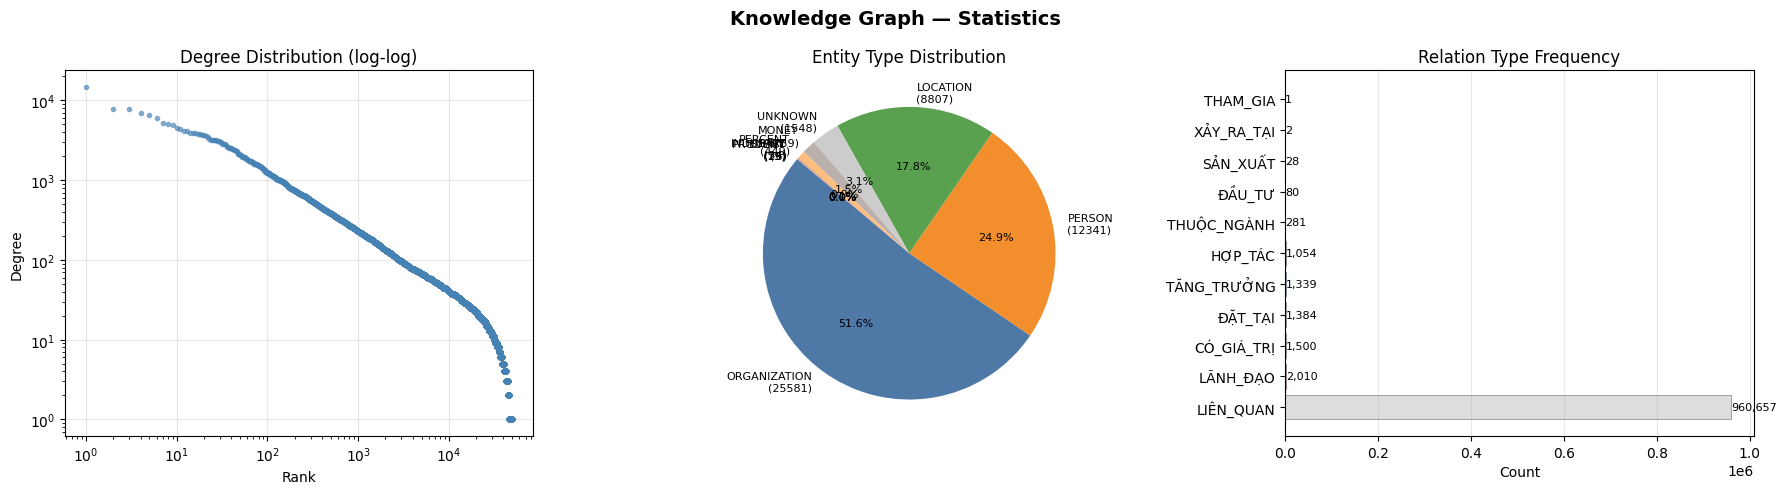

Saved: knowledge_graph_output\graph_statistics.png


In [15]:
# ── Plot 1: Degree Distribution ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Knowledge Graph — Statistics', fontsize=14, fontweight='bold')

degree_vals = sorted(degrees.values(), reverse=True)
ax = axes[0]
ax.loglog(range(1, len(degree_vals) + 1), degree_vals, 'o', markersize=3,
          color='steelblue', alpha=0.6)
ax.set_xlabel('Rank')
ax.set_ylabel('Degree')
ax.set_title('Degree Distribution (log-log)')
ax.grid(True, alpha=0.3)

# ── Plot 2: Entity type pie ──────────────────────────────────
ax = axes[1]
type_cnt = Counter(d.get('entity_type', 'UNKNOWN') for _, d in G.nodes(data=True))
labels = [f"{k}\n({v})" for k, v in type_cnt.most_common()]
colors = [ETYPE_COLOR.get(k, '#CCCCCC') for k, _ in type_cnt.most_common()]
ax.pie(
    [v for _, v in type_cnt.most_common()],
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 8},
)
ax.set_title('Entity Type Distribution')

# ── Plot 3: Relation type bar ────────────────────────────────
ax = axes[2]
rel_items = rel_freq.most_common()
rel_names  = [r for r, _ in rel_items]
rel_counts = [c for _, c in rel_items]
rel_colors = [RELATION_COLOR.get(r, '#999999') for r in rel_names]
bars = ax.barh(rel_names, rel_counts, color=rel_colors, edgecolor='gray', linewidth=0.5)
for bar, cnt in zip(bars, rel_counts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{cnt:,}', va='center', fontsize=8)
ax.set_xlabel('Count')
ax.set_title('Relation Type Frequency')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
fig_path = OUT / 'graph_statistics.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## 12. Sample Triples & Quality Check

In [19]:
import random
random.seed(42)

print('=' * 65)
print('SAMPLE TRIPLES BY RELATION TYPE')
print('=' * 65)

# Group triples theo relation
rel_groups: Dict[str, List[Triple]] = defaultdict(list)
for t in triples_filtered:
    rel_groups[t.relation].append(t)

for relation, group in sorted(rel_groups.items()):
    print(f'\n── {relation} ({len(group):,} triples) ──')
    samples = random.sample(group, min(3, len(group)))
    for t in samples:
        print(f'  [{t.subject_type:12s}] "{t.subject}"')
        print(f'   ──{t.relation}──→  (conf={t.confidence:.2f})')
        print(f'  [{t.obj_type:12s}] "{t.obj}"')
        if t.source_text:
            print(f'  Source: "{t.source_text[:80]}..."')
        print()

# ── Coverage stats ───────────────────────────────────────────
print('=' * 65)
print('COVERAGE')
print('=' * 65)
total_rows = len(df)
rows_with_triple = len(set(t.source_id for t in triples_filtered))
print(f'Rows có ≥1 triple     : {rows_with_triple:,} / {total_rows:,} ({rows_with_triple/total_rows*100:.1f}%)')
print(f'Rows không có triple  : {total_rows - rows_with_triple:,} ({(total_rows-rows_with_triple)/total_rows*100:.1f}%)')
print(f'Avg triples / row     : {len(triples_filtered) / rows_with_triple:.2f}')

# Confidence distribution
confs = [t.confidence for t in triples_filtered]
print(f'\nConfidence distribution:')
print(f'  min    : {min(confs):.3f}')
print(f'  mean   : {np.mean(confs):.3f}')
print(f'  median : {np.median(confs):.3f}')
print(f'  max    : {max(confs):.3f}')

SAMPLE TRIPLES BY RELATION TYPE

── CÓ_GIÁ_TRỊ (1,500 triples) ──
  [ORGANIZATION] "Tổng Công ty Bảo hiểm Bảo Việt"
   ──CÓ_GIÁ_TRỊ──→  (conf=0.75)
  [MONEY       ] "3.171 tỷ đồng"
  Source: "Lĩnh vực kinh doanh bảo hiểm tăng trưởng tốt Lĩnh vực kinh doanh bảo hiểm phi nh..."

  [UNKNOWN     ] "Ông còn nhận được gói quyền chọn cổ phiếu"
   ──CÓ_GIÁ_TRỊ──→  (conf=0.75)
  [UNKNOWN     ] "9,6 triệu USD"
  Source: "Ông còn nhận được gói quyền chọn cổ phiếu trị giá 9,6 triệu USD cũng như thưởng ..."

  [UNKNOWN     ] "Tổng tài sản"
   ──CÓ_GIÁ_TRỊ──→  (conf=0.75)
  [UNKNOWN     ] "204.851 tỷ đồng"
  Source: "Cụ thể, tính đến hết ngày 30/6/2025, quy mô hoạt động của ABBank ghi nhận sự tăn..."


── HỢP_TÁC (1,054 triples) ──
  [ORGANIZATION] "CAC"
   ──HỢP_TÁC──→  (conf=0.80)
  [ORGANIZATION] "Apple"
  Source: "Apple không phải là công ty nước ngoài đầu tiên hợp tác với CAC về các vấn đề li..."

  [ORGANIZATION] "Vinmec"
   ──HỢP_TÁC──→  (conf=0.80)
  [ORGANIZATION] "Stratasys"
  Source: "Hợp

## 13. Tổng kết

### Pipeline Bước 3: Tạo Knowledge Graph

| Bước | Mô tả | Output |
|------|-------|--------|
| **Parse BIO** | Đọc `ner_labeled_data.csv`, parse BIO labels → entity spans | `List[EntitySpan]` |
| **Normalization** | Unicode NFC, alias resolution, length filter | Entity text chuẩn hóa |
| **Rule-based RE** | 10 pattern cú pháp tiếng Việt | `List[Triple]` |
| **Co-occurrence** | Fallback cho câu ngắn (< 150 chars) | Triple `LIÊN_QUAN` |
| **Filtering** | Confidence ≥ 0.5, noise removal, deduplication | Triple quality |
| **Graph Build** | NetworkX MultiDiGraph | `G` |
| **Export** | CSV, JSON, GraphML, GEXF, HTML | 5 file format |

### Relation Types

| Relation | Subj | Obj | Conf |
|----------|------|-----|------|
| `LÃNH_ĐẠO` | PERSON | ORG | 0.85 |
| `HỢP_TÁC` | ORG | ORG | 0.80 |
| `ĐẦU_TƯ` | ORG/PERSON | ORG | 0.82 |
| `SẢN_XUẤT` | ORG | PRODUCT | 0.78 |
| `ĐẶT_TẠI` | ORG | LOC | 0.75 |
| `THUỘC_NGÀNH` | ORG | INDUSTRY | 0.72 |
| `TỔ_CHỨC_SỰ_KIỆN` | ORG | EVENT | 0.78 |
| `CÓ_GIÁ_TRỊ` | any | MONEY | 0.75 |
| `XẢY_RA_TẠI` | EVENT | LOC | 0.76 |
| `THAM_GIA` | PERSON | EVENT | 0.73 |
| `TĂNG_TRƯỞNG` | any | PERCENT | 0.70 |
| `LIÊN_QUAN` | ORG/PERSON | ORG/LOC | 0.50 |

### Output Files

| File | Dùng cho |
|------|----------|
| `triples.csv` | Phân tích, Power BI, Excel |
| `triples.json` | API, downstream tasks |
| `knowledge_graph.graphml` | **Input Bước 4** (NetworkX, Gephi, Cytoscape) |
| `knowledge_graph.gexf` | Gephi real-time |
| `graph_statistics.png` | Báo cáo |
| `graph_top_nodes.png` | Báo cáo |
